## MODEL DEVELOPMENT

In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import gaussian_kde
import sys

BASE          = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR   = BASE / "data/processed/patches"
STATS_PATH    = PATCHES_DIR / "stats.json"
METADATA_PATH = PATCHES_DIR / "metadata.json"
sys.path.insert(0, str(BASE))

with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN    = stats_data["hr"]["mean"]
HR_STD     = stats_data["hr"]["std"]
LR_MEAN    = stats_data["lr"]["mean"]
LR_STD     = stats_data["lr"]["std"]
DATA_RANGE = stats_data["hr_data_range"]
DATA_MIN   = stats_data["hr_percentiles"]["p1"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
from scripts.utils.dataset import SRDataset

test_ds = SRDataset(
    split="test",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,
    aux_dir=str(PATCHES_DIR / "test" / "AUX"),
    repeat_channels=False,
    transform=None,
)
print(f"test set size: {len(test_ds)} samples")

test set size: 72 samples


In [ ]:
from scripts.models.realesrgan import RealESRGANModule

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = str(BASE / "checkpoints/dev_gan/direct4_epoch=46_val/water_mae=1.0145.ckpt") 
model = RealESRGANModule.load_from_checkpoint(MODEL_PATH, strict=True).to(device).eval()

#checkpoints/dev_gan/projected4_epoch=47_val/water_mae=1.1074.ckpt #projected
#checkpoints/dev_gan/direct4_epoch=46_val/water_mae=1.0145.ckpt  #direct

In [4]:
np.random.seed(42)
N_SAMPLES   = 5
vis_indices = np.random.choice(len(test_ds), N_SAMPLES, replace=False)
vis_samples = [test_ds[i] for i in vis_indices]
print(f"\nSelected tiles for viz: {[s['fname'] for s in vis_samples]}")


Selected tiles for viz: ['BRC_2022_b0_r1280_c768.npy', 'HAUT_2025_b0_r4864_c1792.npy', 'BRC_2023_b0_r256_c0.npy', 'BRC_2022_b0_r0_c0.npy', 'HAUT_2025_b0_r1536_c3840.npy']


In [5]:
def prep_sample(sample):
    hr_mask = sample["hr_mask"].squeeze().numpy()
    lr_64   = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256  = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    lr_np   = np.where(hr_mask > 0.5, lr_256, np.nan)
    hr_np   = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    hr_np   = np.where(hr_mask > 0.5, hr_np, np.nan)
    valid   = hr_np[hr_mask > 0.5]
    vmin    = np.nanpercentile(valid, 2)
    vmax    = np.nanpercentile(valid, 98)
    return lr_np, hr_np, hr_mask, vmin, vmax


def run_inference(sample):
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}
    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)
    if "time_channels" in sample:
        batch["time_channels"] = sample["time_channels"].unsqueeze(0).to(device)
    with torch.no_grad():
        sr = model(batch)
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()
    return sr_celsius

# def run_inference(sample):
#     batch = {"lr": sample["lr"].unsqueeze(0).to(device)}
#     if "aux" in sample:
#         batch["aux"] = sample["aux"].unsqueeze(0).to(device)
#     with torch.no_grad():
#         sr = model(batch)
#     print(f"SR raw min: {sr.min():.3f} max: {sr.max():.3f} mean: {sr.mean():.3f}")
#     sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()
#     print(f"SR celsius min: {sr_celsius.min():.1f} max: {sr_celsius.max():.1f}")
#     return sr_celsius

### projected aux

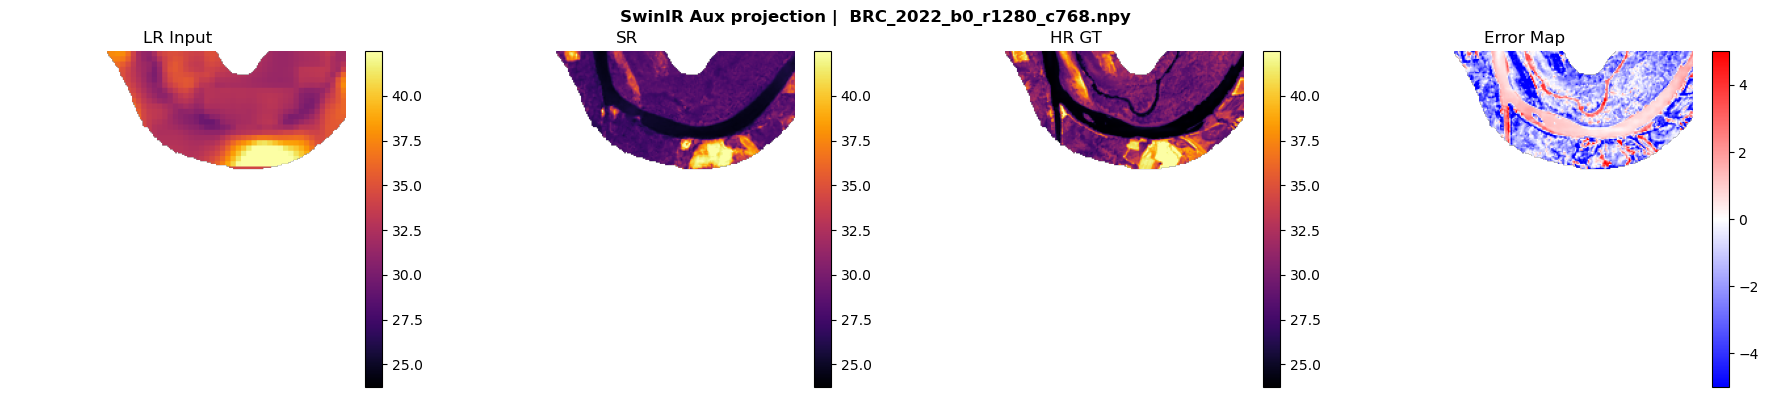

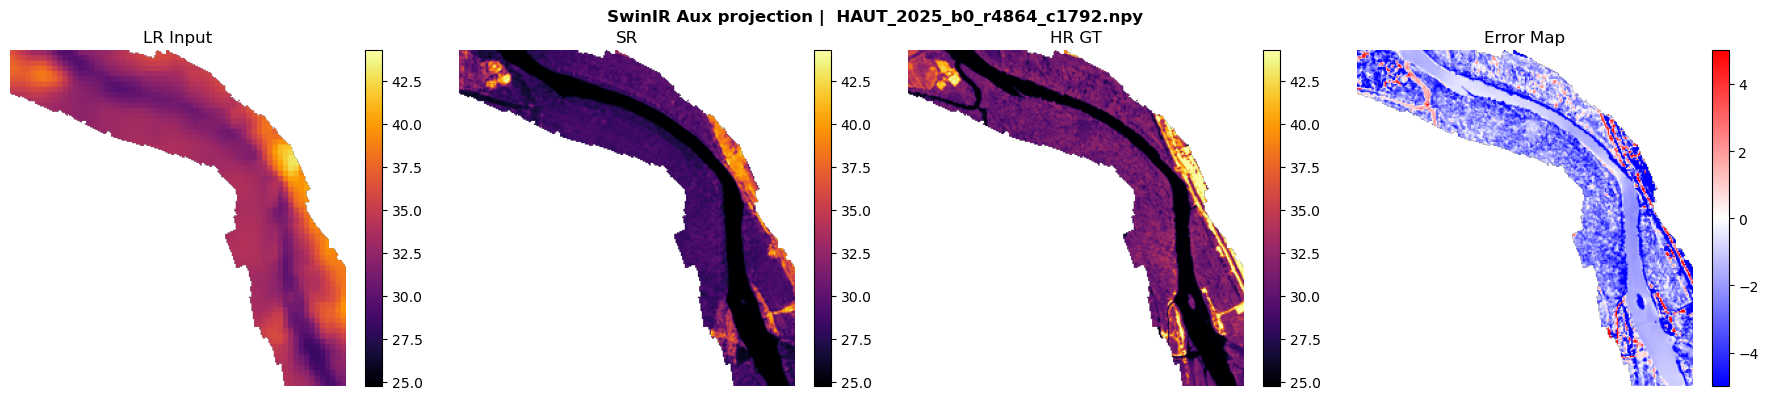

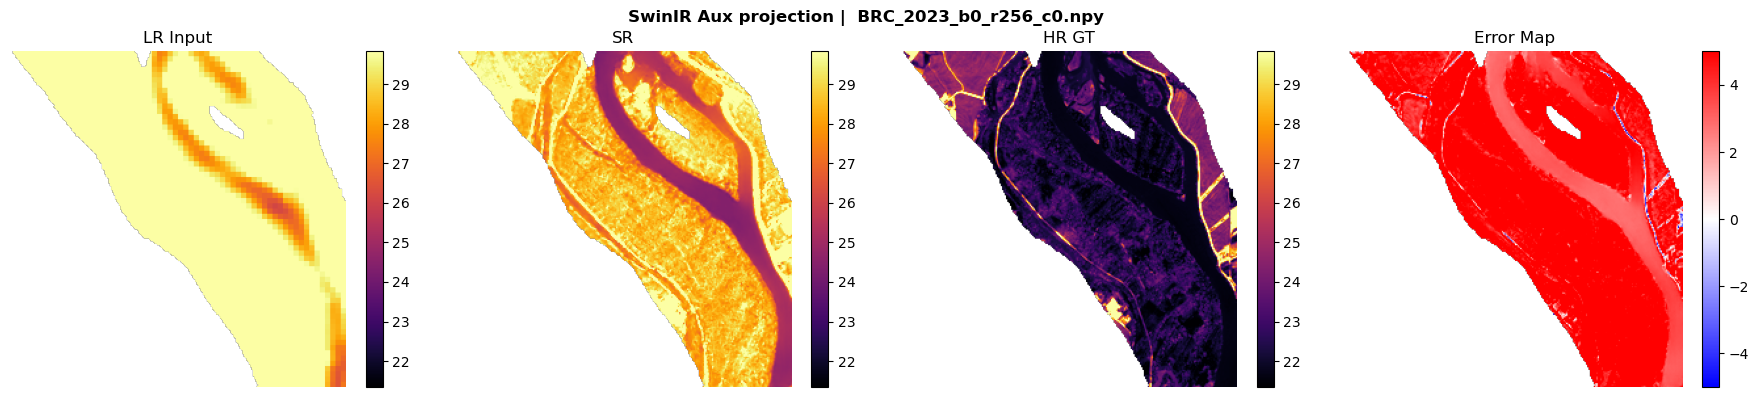

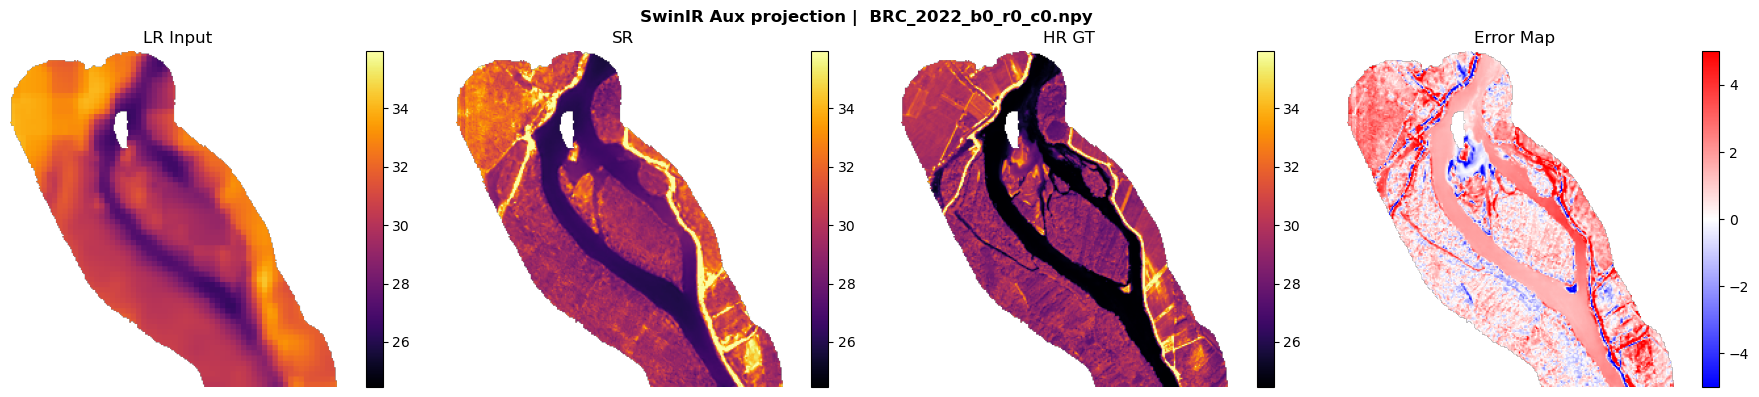

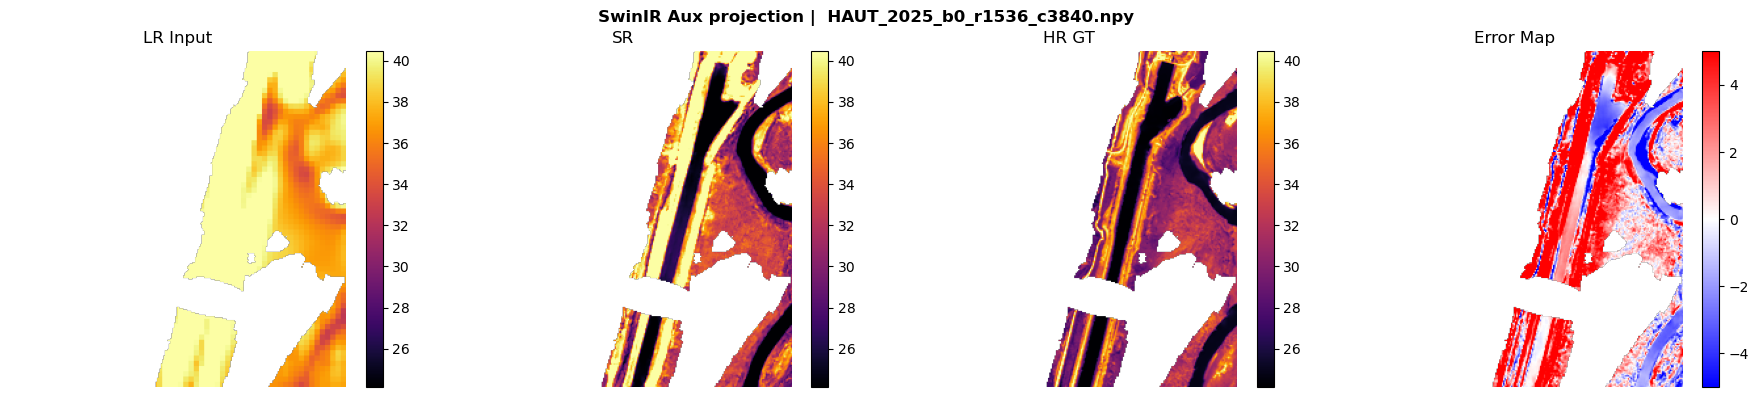

In [9]:
for sample in vis_samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)
    sr_celsius = run_inference(sample)
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    residual = sr_celsius - hr_np
    res_lim  = (np.nanmax(np.abs(residual)) if np.isfinite(residual).any() else 5)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"SwinIR Aux projection |  {fname}", fontsize=12, fontweight="bold")

    im = axes[0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR Input"); axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    im = axes[1].imshow(sr_celsius, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR"); axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    im = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR GT"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    im = axes[3].imshow(residual, cmap="bwr", vmin=-5, vmax=5)
    axes[3].set_title("Error Map"); axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()
    torch.cuda.empty_cache()


Running inference on full val set (72 samples)...


  50/72 done
  72/72 done
Total valid pixels: 440,308


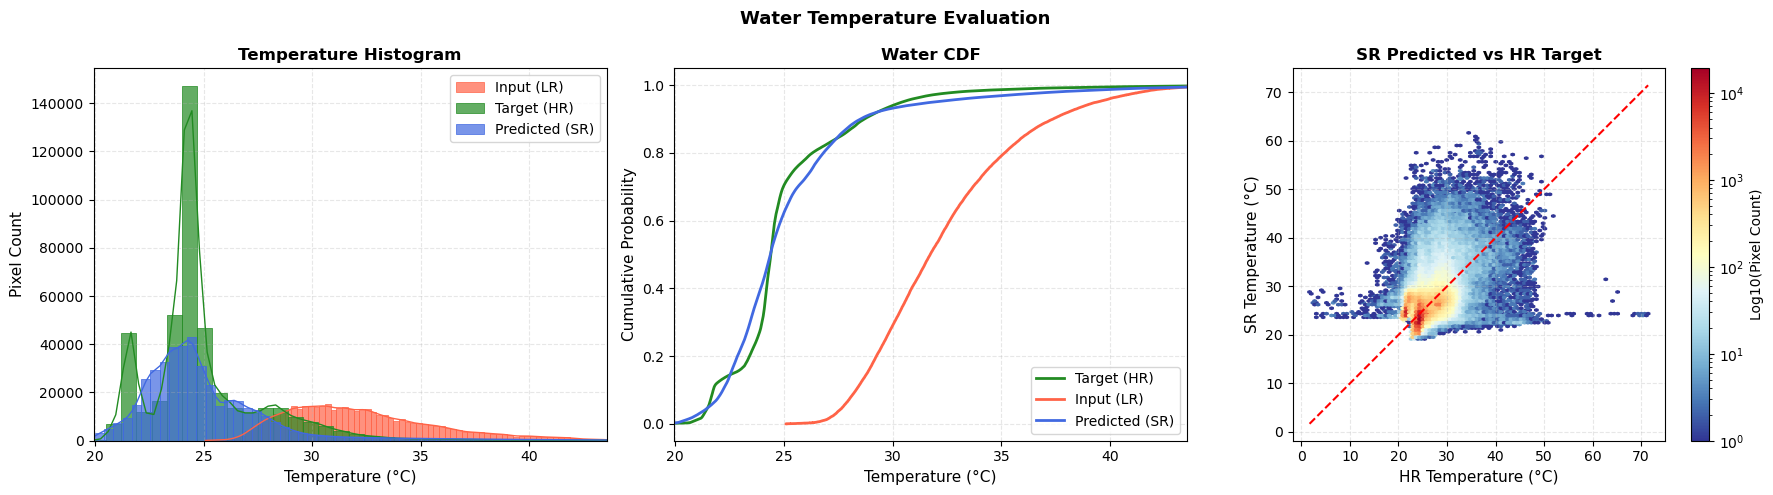

In [11]:
print(f"\nRunning inference on full val set ({len(test_ds)} samples)...")

all_hr, all_sr, all_lr = [], [], []

for i, sample in enumerate(test_ds):
    hr_mask    = sample["hr_mask"].squeeze().numpy()
    water_mask = sample["water_mask"].squeeze().numpy()

    valid_mask = (hr_mask > 0.5) & (water_mask > 0.5)

    if valid_mask.sum() == 0:
        continue

    lr_64  = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    hr_np  = sample["hr"][0].numpy() * HR_STD + HR_MEAN

    sr_celsius = run_inference(sample)

    all_hr.append(hr_np[valid_mask])
    all_sr.append(sr_celsius[valid_mask])
    all_lr.append(lr_256[valid_mask])

    if (i + 1) % 50 == 0 or (i + 1) == len(test_ds):
        print(f"  {i + 1}/{len(test_ds)} done")

    torch.cuda.empty_cache()

hr_valid = np.concatenate(all_hr)
sr_valid = np.concatenate(all_sr)
lr_valid = np.concatenate(all_lr)
print(f"Total valid pixels: {len(hr_valid):,}")

# --- Common Limits for Histogram and CDF ---
padding = 1.0  
xmin = np.percentile(hr_valid, 1) - padding
xmax = np.percentile(lr_valid, 99) + padding

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Water Temperature Evaluation", fontsize=13, fontweight="bold")

# Palette setup
palette = {"HR": "forestgreen", "SR": "royalblue", "LR": "tomato"}

# ---------------- Panel 1: Histogram + KDE ----------------
ax_hist = axes[0]
# Plotting order: Input (LR) background, Target (HR) and Predicted (SR) foreground
for vec, key, lbl in [(lr_valid, "LR", "Input (LR)"), 
                      (hr_valid, "HR", "Target (HR)"), 
                      (sr_valid, "SR", "Predicted (SR)")]:
    
    sns.histplot(
        vec,
        ax=ax_hist,
        bins=100,
        stat="count",              # ← Y-axis becomes raw Pixel Count
        kde=True,                  # ← Automatically scales the KDE line to match Pixel Counts!
        color=palette[key],
        label=lbl,
        alpha=0.7,                # Soft bar shading
        edgecolor=palette[key],        
        linewidth=0.5,
        line_kws={"linewidth": 1.0}  # Smooth KDE curve thickness
    )

ax_hist.set_title("Temperature Histogram", fontsize=12, fontweight="bold")
ax_hist.set_xlabel("Temperature (°C)", fontsize=11)
ax_hist.set_ylabel("Pixel Count", fontsize=11)            # Raw pixel count
ax_hist.set_xlim(xmin, xmax)
ax_hist.grid(True, linestyle="--", alpha=0.3)
ax_hist.legend(loc="upper right", frameon=True)

# ---------------- Panel 2: Water CDF ----------------
ax_cdf = axes[1]
for vec, key, lbl in [(hr_valid, "HR", "Target (HR)"), 
                      (lr_valid, "LR", "Input (LR)"),
                      (sr_valid, "SR", "Predicted (SR)")]:
    
    sorted_data = np.sort(vec)
    y_values = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax_cdf.plot(sorted_data, y_values, color=palette[key], lw=2.0, label=lbl)

ax_cdf.set_title("Water CDF", fontsize=12, fontweight="bold")
ax_cdf.set_xlabel("Temperature (°C)", fontsize=11)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=11)
ax_cdf.set_xlim(xmin, xmax) 
ax_cdf.grid(True, linestyle="--", alpha=0.3)
ax_cdf.legend(loc="lower right", frameon=True)

# ---------------- Panel 3: Hexbin (1:1 Scatter) ----------------
ax_scat = axes[2]
hb = ax_scat.hexbin(
    hr_valid, sr_valid, 
    gridsize=100, 
    cmap="RdYlBu_r", 
    mincnt=1, 
    bins='log'
)

global_min, global_max = min(hr_valid.min(), sr_valid.min()), max(hr_valid.max(), sr_valid.max())
ax_scat.plot([global_min, global_max], [global_min, global_max], "r--", lw=1.5)

ax_scat.set_title("SR Predicted vs HR Target", fontsize=12, fontweight="bold")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=11)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=11)
ax_scat.set_aspect("equal")
ax_scat.grid(True, linestyle="--", alpha=0.3)
fig.colorbar(hb, ax=ax_scat, label="Log10(Pixel Count)")

plt.tight_layout()
plt.show()

### modified first layer

In [6]:
TARGET_TILES = ["HAUT_2025_b0_r1792_c3840.npy"]
# HAUT_2025_b0_r4608_c1536.npy #initial sample

samples = []
for idx in range(len(test_ds)):
    # Check if target name matches (handles with or without .npy extension)
    current_fname = str(test_ds[idx]["fname"])
    if any(target in current_fname for target in TARGET_TILES):
        samples.append(test_ds[idx])

if not samples:
    raise ValueError(f"None of the target tiles {TARGET_TILES} were found in test_ds!")

print(f"Selected tiles: {[s['fname'] for s in samples]}")


Selected tiles: ['HAUT_2025_b0_r1792_c3840.npy']


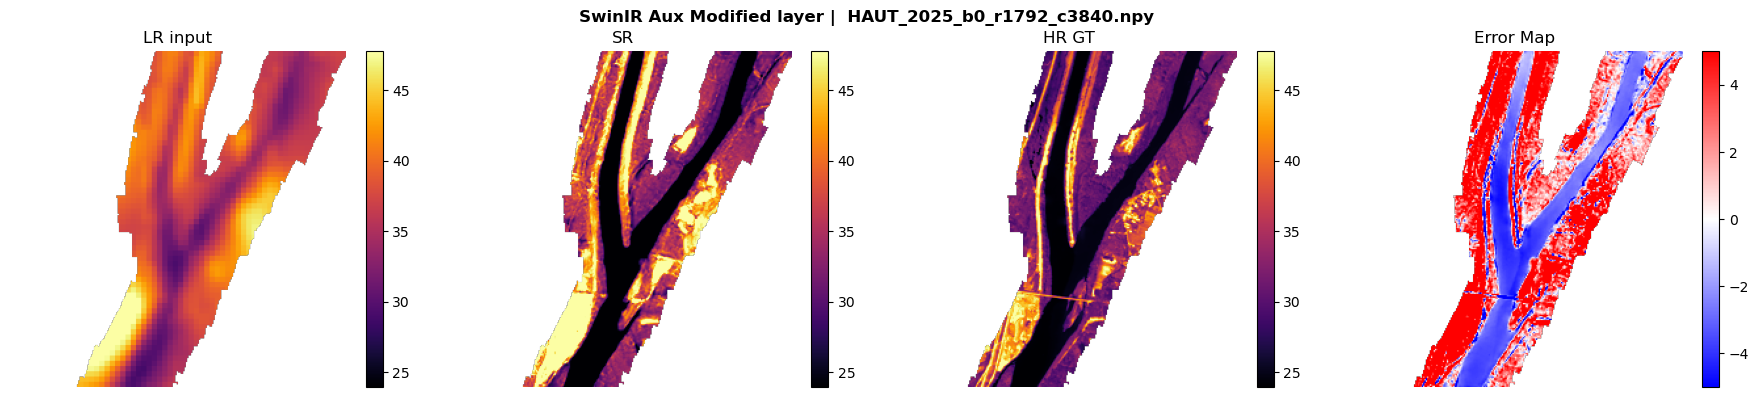

In [7]:
for sample in samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)
    sr_celsius = run_inference(sample)
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    residual = sr_celsius - hr_np
    res_lim  = (np.nanmax(np.abs(residual)) if np.isfinite(residual).any() else 5)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"SwinIR Aux Modified layer |  {fname}", fontsize=12, fontweight="bold")

    im = axes[0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR input"); axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    im = axes[1].imshow(sr_celsius, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR"); axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    im = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR GT"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    im = axes[3].imshow(residual, cmap="bwr", vmin=-5, vmax=5)
    axes[3].set_title("Error Map"); axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()
    torch.cuda.empty_cache()

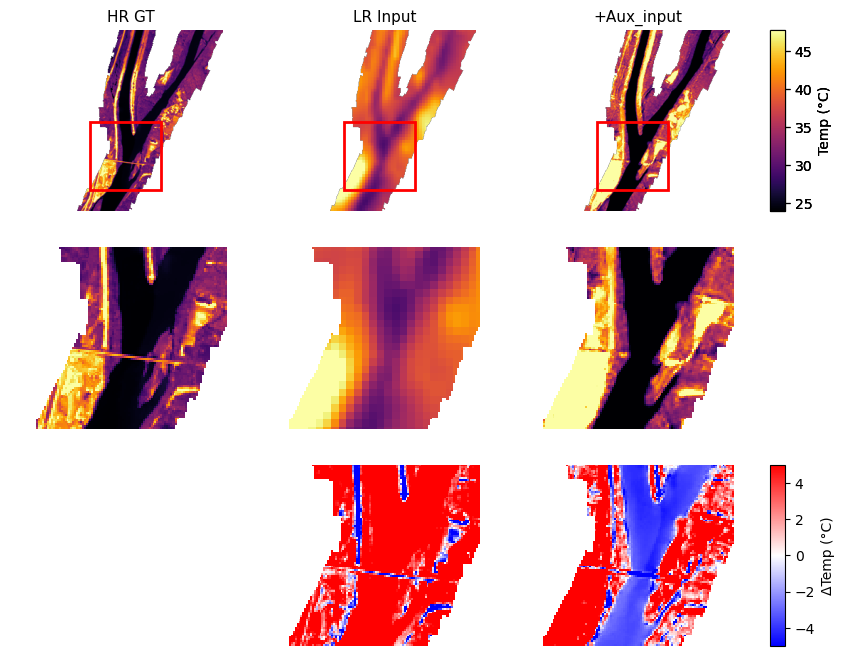

In [23]:
import os
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom  # or use cv2.resize / torchvision

# --- DEFINE YOUR BOX IN PIXELS ---
x, y, w, h = 70, 130, 100, 95  # top-left corner + size
row_slice = slice(y, y + h)  # derive slices once, reuse everywhere
col_slice = slice(x, x + w)

COL_LABELS = ["HR GT", "LR Input", "+Aux_input"] 

def add_zoom_box(ax, x, y, w, h, color="red", lw=2):
    ax.add_patch(
        mpatches.Rectangle(
            (x, y), w, h, linewidth=lw, edgecolor=color, facecolor="none"
        )
    )

for sample in samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # --- 1. UPSAMPLE LR TO HR RESOLUTION (if not already 256x256) ---
    if lr_np.shape != hr_np.shape:
        zoom_factors = (
            hr_np.shape[0] / lr_np.shape[0],
            hr_np.shape[1] / lr_np.shape[1],
        )
        lr_bicubic = zoom(lr_np, zoom_factors, order=3)  # order=3 is bicubic
    else:
        lr_bicubic = lr_np.copy()

    # Mask bicubic LR image
    lr_bicubic_masked = np.where(hr_mask > 0.5, lr_bicubic, np.nan)

    # --- 2. CALCULATE MODEL MAPS & RESIDUALS ---
    sr_maps, residuals = {}, {}

    # Calculate Bicubic Residual first
    residuals_ = np.where(hr_mask > 0.5, lr_bicubic_masked - hr_np, np.nan)

    sr_np = run_inference(sample)
    sr_np = np.where(hr_mask > 0.5, sr_np, np.nan)
    # sr_maps[model] = sr_np
    residuals = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)

    full_panels = [hr_np, lr_bicubic_masked, sr_np] 

    # --- 3. PLOTTING ---
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(
        3,
        4,
        width_ratios=[1, 1, 1, 0.06],
        hspace=0.2,
        wspace=0.06,
        figure=fig,
    )


    # Row 0: Full Patches
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[0, c])
        temp_im = ax.imshow(arr, cmap="inferno", vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=11)
        ax.axis("off")
        add_zoom_box(ax, x, y, w, h)
        fig.colorbar(temp_im, cax=fig.add_subplot(gs[0, 3]), label="Temp (°C)")

    # Row 1: Zoomed Crops
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[1, c])
        ax.imshow(
            arr[row_slice, col_slice],
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.axis("off")

    # Row 2: Error Maps
    # Column 0: Blank under HR (HR - HR = 0)
    fig.add_subplot(gs[2, 0]).axis("off")

    # Column 1: LR / Bicubic Residual
    ax_lr_err = fig.add_subplot(gs[2, 1])
    err_im = ax_lr_err.imshow(
        residuals_[row_slice, col_slice],
        cmap="bwr",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax_lr_err.axis("off")

    # Columns 2+: Model Residuals
    ax = fig.add_subplot(gs[2, 2 + 0])
    err_im = ax.imshow(
        residuals[row_slice, col_slice],
        cmap="bwr",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax.axis("off")
    fig.colorbar(err_im, cax=fig.add_subplot(gs[2, 3]), label="ΔTemp (°C)")

    # --- 4. SAVE FIGURE ---
    plt.savefig(
        "direct_aux.png", transparent=True, dpi=600, bbox_inches="tight", pad_inches=0
    )
    plt.show()
    plt.close(fig)  # Prevents notebook memory leaks across loops



Running inference on full val set (72 samples)...
  50/72 done
  72/72 done
Total valid pixels: 440,308


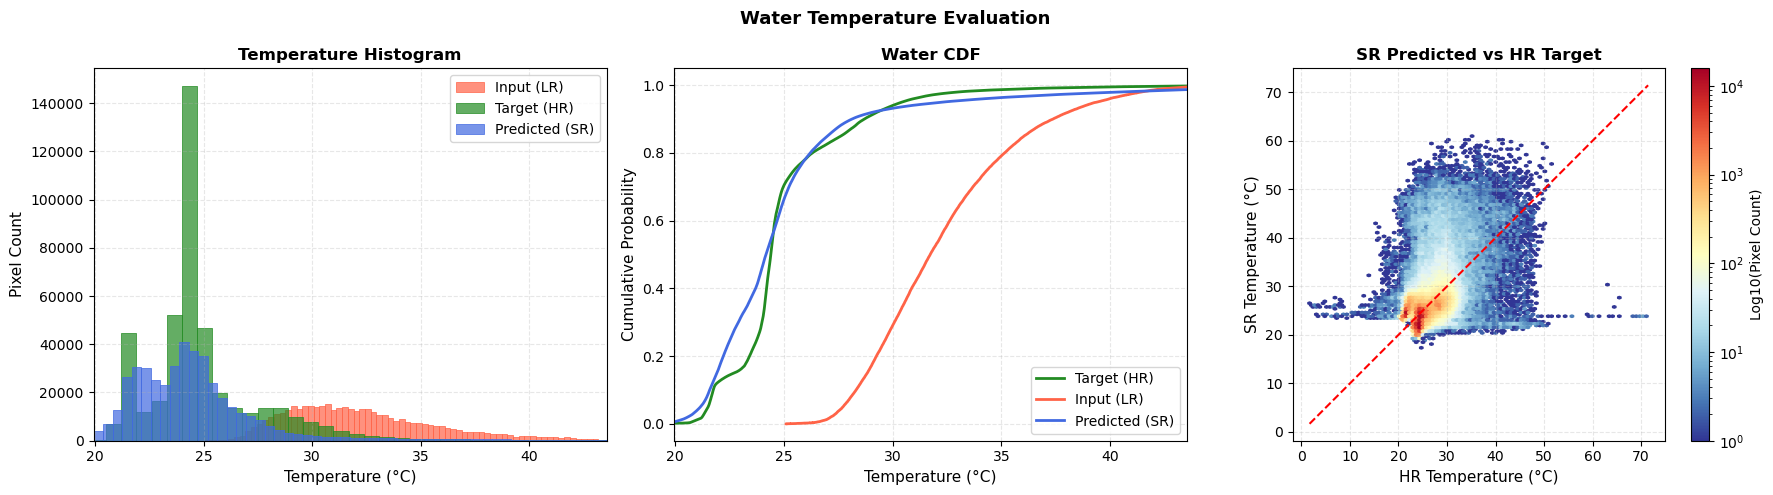

In [37]:
print(f"\nRunning inference on full val set ({len(test_ds)} samples)...")

all_hr, all_sr, all_lr = [], [], []

for i, sample in enumerate(test_ds):
    hr_mask    = sample["hr_mask"].squeeze().numpy()
    water_mask = sample["water_mask"].squeeze().numpy()

    valid_mask = (hr_mask > 0.5) & (water_mask > 0.5)

    if valid_mask.sum() == 0:
        continue

    lr_64  = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    hr_np  = sample["hr"][0].numpy() * HR_STD + HR_MEAN

    sr_celsius = run_inference(sample)

    all_hr.append(hr_np[valid_mask])
    all_sr.append(sr_celsius[valid_mask])
    all_lr.append(lr_256[valid_mask])

    if (i + 1) % 50 == 0 or (i + 1) == len(test_ds):
        print(f"  {i + 1}/{len(test_ds)} done")

    torch.cuda.empty_cache()

hr_valid = np.concatenate(all_hr)
sr_valid = np.concatenate(all_sr)
lr_valid = np.concatenate(all_lr)
print(f"Total valid pixels: {len(hr_valid):,}")

# --- Common Limits for Histogram and CDF ---
padding = 1.0  
xmin = np.percentile(hr_valid, 1) - padding
xmax = np.percentile(lr_valid, 99) + padding

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Water Temperature Evaluation", fontsize=13, fontweight="bold")

# Palette setup
palette = {"HR": "forestgreen", "SR": "royalblue", "LR": "tomato"}

# ---------------- Panel 1: Histogram + KDE ----------------
ax_hist = axes[0]
# Plotting order: Input (LR) background, Target (HR) and Predicted (SR) foreground
for vec, key, lbl in [(lr_valid, "LR", "Input (LR)"), 
                      (hr_valid, "HR", "Target (HR)"), 
                      (sr_valid, "SR", "Predicted (SR)")]:
    
    sns.histplot(
        vec,
        ax=ax_hist,
        bins=100,
        stat="count",              # ← Y-axis becomes raw Pixel Count
        kde=False,                  # ← Automatically scales the KDE line to match Pixel Counts!
        color=palette[key],
        label=lbl,
        alpha=0.7,                # Soft bar shading
        edgecolor=palette[key],        
        linewidth=0.5,
        line_kws={"linewidth": 1.0}  # Smooth KDE curve thickness
    )

ax_hist.set_title("Temperature Histogram", fontsize=12, fontweight="bold")
ax_hist.set_xlabel("Temperature (°C)", fontsize=11)
ax_hist.set_ylabel("Pixel Count", fontsize=11)            # Raw pixel count
ax_hist.set_xlim(xmin, xmax)
ax_hist.grid(True, linestyle="--", alpha=0.3)
ax_hist.legend(loc="upper right", frameon=True)

# ---------------- Panel 2: Water CDF ----------------
ax_cdf = axes[1]
for vec, key, lbl in [(hr_valid, "HR", "Target (HR)"), 
                      (lr_valid, "LR", "Input (LR)"),
                      (sr_valid, "SR", "Predicted (SR)")]:
    
    sorted_data = np.sort(vec)
    y_values = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax_cdf.plot(sorted_data, y_values, color=palette[key], lw=2.0, label=lbl)

ax_cdf.set_title("Water CDF", fontsize=12, fontweight="bold")
ax_cdf.set_xlabel("Temperature (°C)", fontsize=11)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=11)
ax_cdf.set_xlim(xmin, xmax) 
ax_cdf.grid(True, linestyle="--", alpha=0.3)
ax_cdf.legend(loc="lower right", frameon=True)

# ---------------- Panel 3: Hexbin (1:1 Scatter) ----------------
ax_scat = axes[2]
hb = ax_scat.hexbin(
    hr_valid, sr_valid, 
    gridsize=100, 
    cmap="RdYlBu_r", 
    mincnt=1, 
    bins='log'
)

global_min, global_max = min(hr_valid.min(), sr_valid.min()), max(hr_valid.max(), sr_valid.max())
ax_scat.plot([global_min, global_max], [global_min, global_max], "r--", lw=1.5)

ax_scat.set_title("SR Predicted vs HR Target", fontsize=12, fontweight="bold")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=11)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=11)
ax_scat.set_aspect("equal")
ax_scat.grid(True, linestyle="--", alpha=0.3)
fig.colorbar(hb, ax=ax_scat, label="Log10(Pixel Count)")

plt.tight_layout()
plt.show()

### loss 

In [ ]:
TARGET_TILES = ["HAUT_2025_b0_r1792_c3840.npy"]
# HAUT_2025_b0_r4608_c1536.npy #initial sample

samples = []
for idx in range(len(test_ds)):
    # Check if target name matches (handles with or without .npy extension)
    current_fname = str(test_ds[idx]["fname"])
    if any(target in current_fname for target in TARGET_TILES):
        samples.append(test_ds[idx])

if not samples:
    raise ValueError(f"None of the target tiles {TARGET_TILES} were found in test_ds!")

print(f"Selected tiles: {[s['fname'] for s in samples]}")


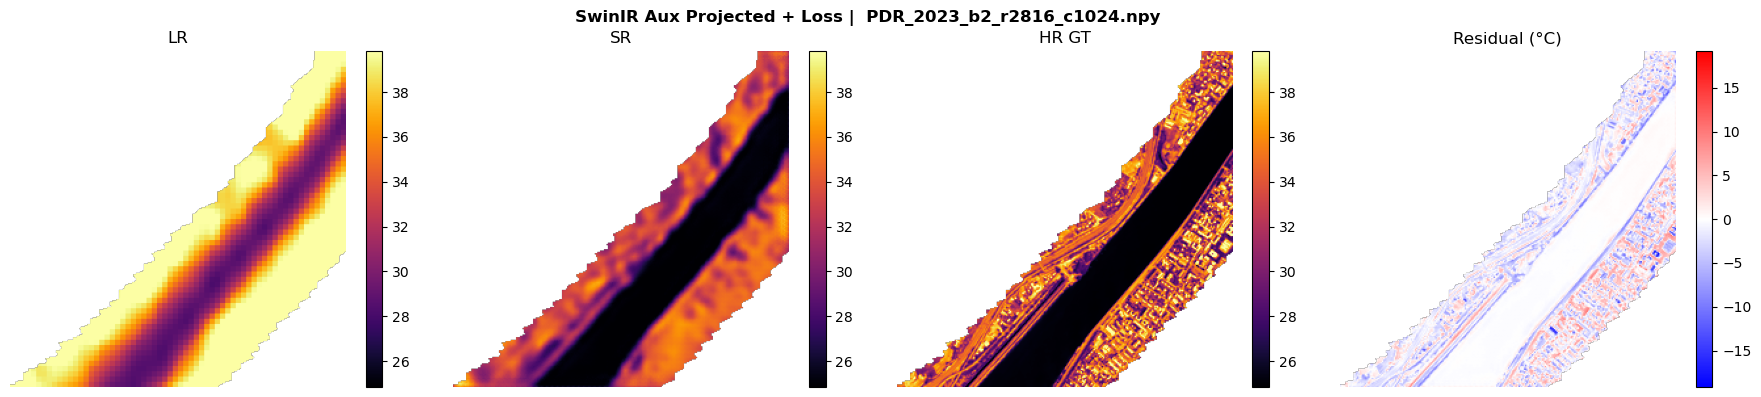

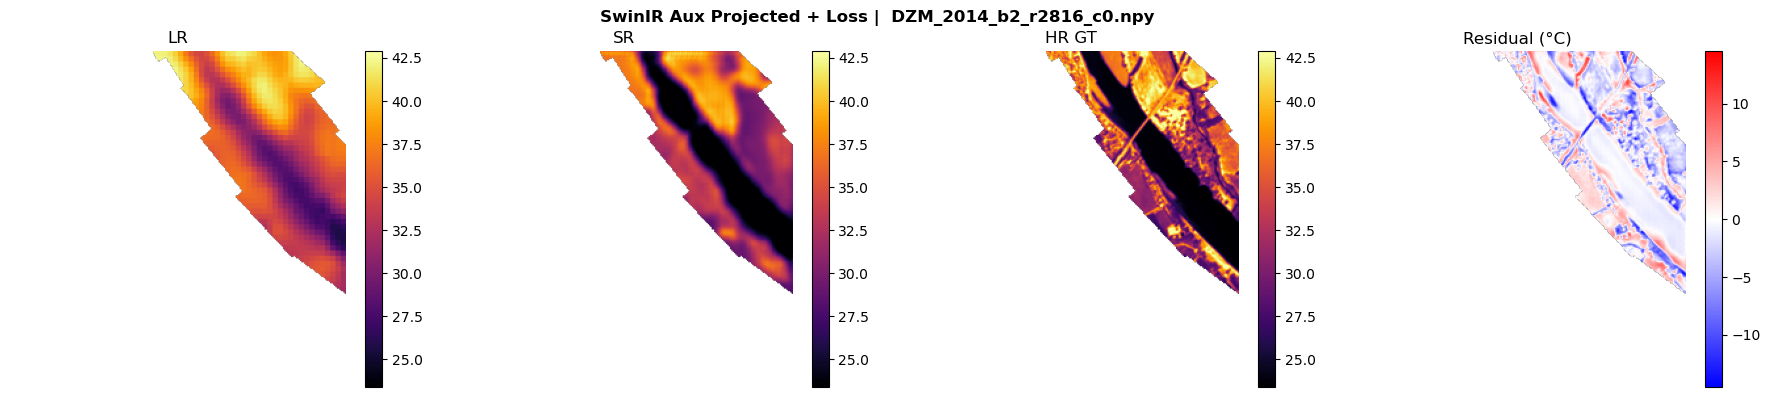

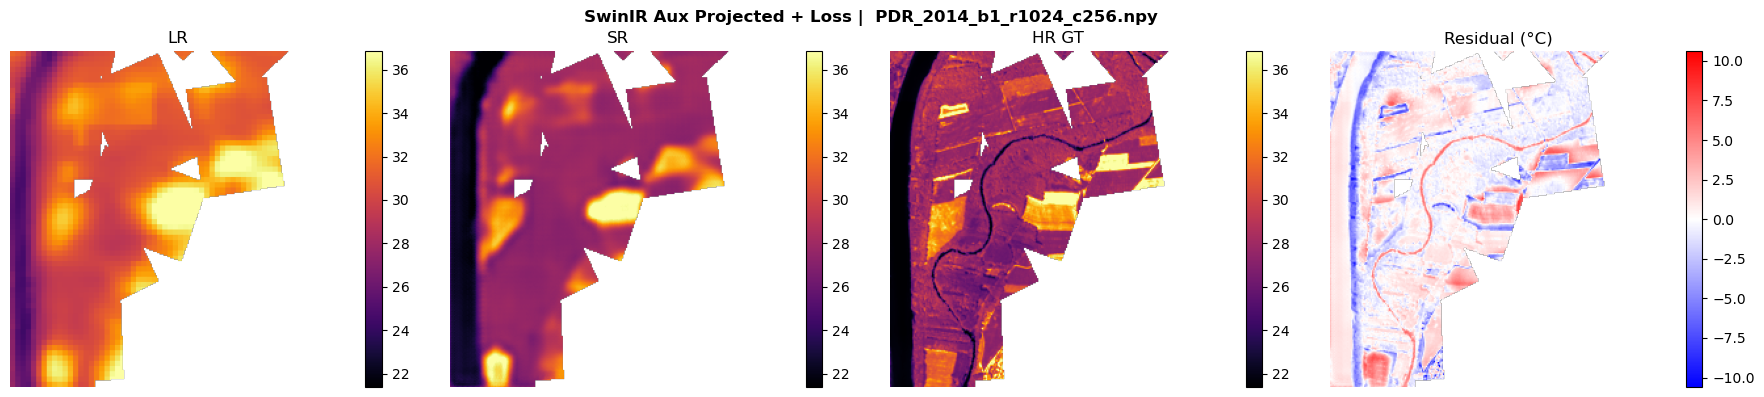

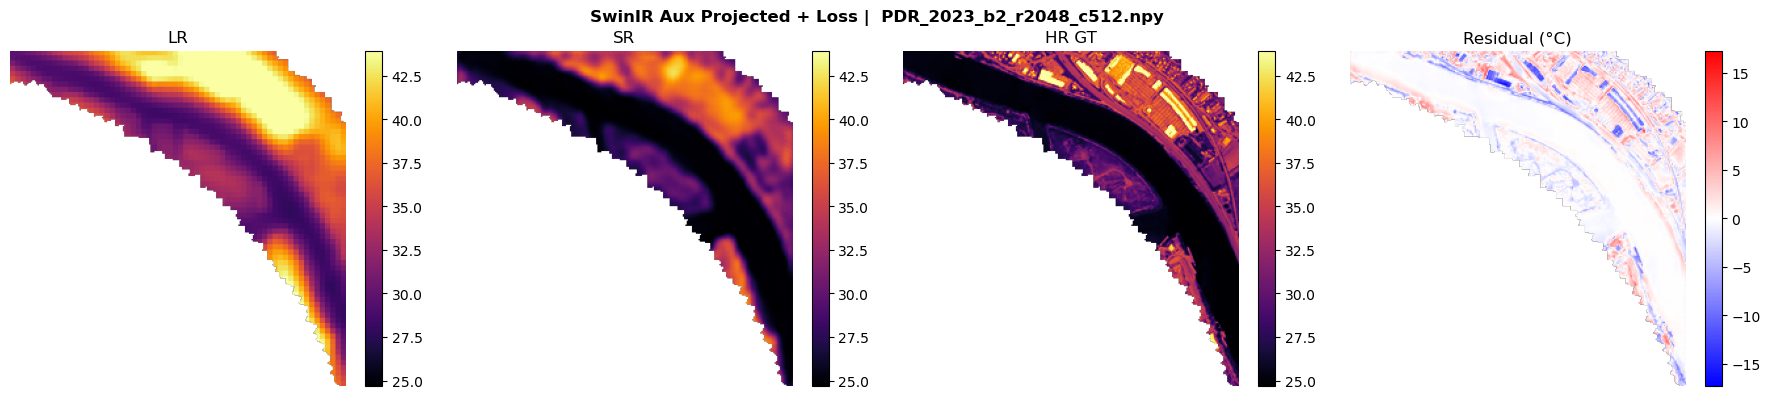

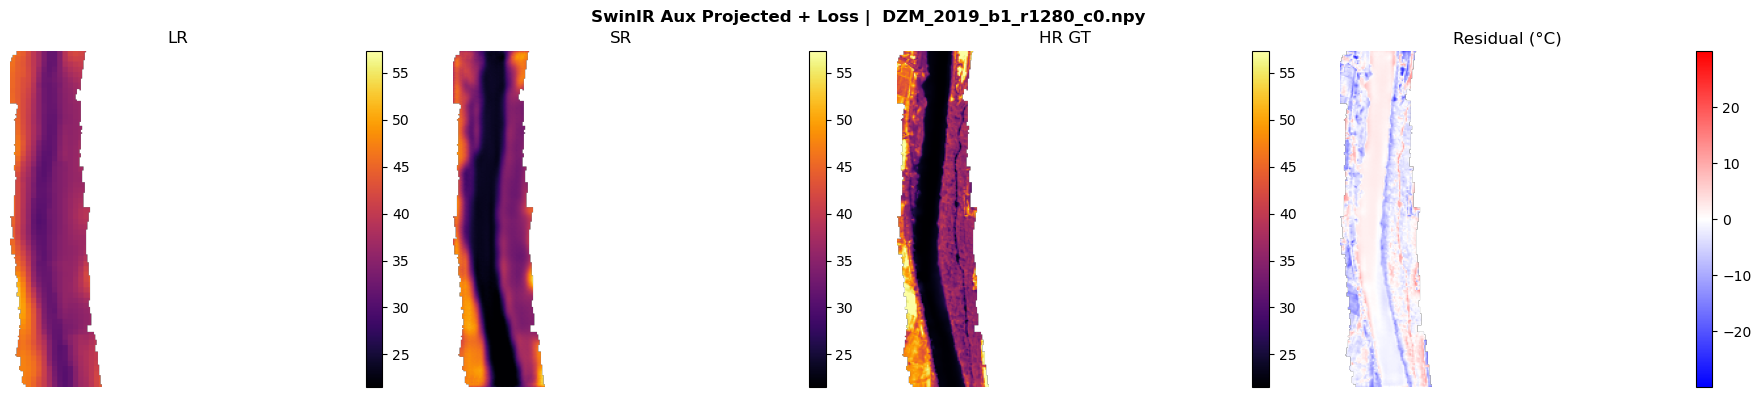

In [ ]:
for sample in samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)
    sr_celsius = run_inference(sample)
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    residual = sr_celsius - hr_np
    res_lim  = (np.nanmax(np.abs(residual)) if np.isfinite(residual).any() else 5)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"SwinIR Aux Projected + Loss |  {fname}", fontsize=12, fontweight="bold")

    im = axes[0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR"); axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    im = axes[1].imshow(sr_celsius, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR"); axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    im = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR GT"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    im = axes[3].imshow(residual, cmap="bwr", vmin=-res_lim, vmax=res_lim)
    axes[3].set_title("Residual (°C)"); axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()
    torch.cuda.empty_cache()

In [ ]:
import os
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom  # or use cv2.resize / torchvision

# --- DEFINE YOUR BOX IN PIXELS ---
x, y, w, h = 70, 130, 100, 95  # top-left corner + size
row_slice = slice(y, y + h)  # derive slices once, reuse everywhere
col_slice = slice(x, x + w)

COL_LABELS = ["HR GT", "LR Input", "+Aux_input"] 

def add_zoom_box(ax, x, y, w, h, color="red", lw=2):
    ax.add_patch(
        mpatches.Rectangle(
            (x, y), w, h, linewidth=lw, edgecolor=color, facecolor="none"
        )
    )

for sample in samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # --- 1. UPSAMPLE LR TO HR RESOLUTION (if not already 256x256) ---
    if lr_np.shape != hr_np.shape:
        zoom_factors = (
            hr_np.shape[0] / lr_np.shape[0],
            hr_np.shape[1] / lr_np.shape[1],
        )
        lr_bicubic = zoom(lr_np, zoom_factors, order=3)  # order=3 is bicubic
    else:
        lr_bicubic = lr_np.copy()

    # Mask bicubic LR image
    lr_bicubic_masked = np.where(hr_mask > 0.5, lr_bicubic, np.nan)

    # --- 2. CALCULATE MODEL MAPS & RESIDUALS ---
    sr_maps, residuals = {}, {}

    # Calculate Bicubic Residual first
    residuals_ = np.where(hr_mask > 0.5, lr_bicubic_masked - hr_np, np.nan)

    sr_np = run_inference(sample)
    sr_np = np.where(hr_mask > 0.5, sr_np, np.nan)
    # sr_maps[model] = sr_np
    residuals = np.where(hr_mask > 0.5, sr_np - hr_np, np.nan)

    full_panels = [hr_np, lr_bicubic_masked, sr_np] 

    # --- 3. PLOTTING ---
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(
        3,
        4,
        width_ratios=[1, 1, 1, 0.06],
        hspace=0.2,
        wspace=0.06,
        figure=fig,
    )


    # Row 0: Full Patches
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[0, c])
        temp_im = ax.imshow(arr, cmap="inferno", vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=11)
        ax.axis("off")
        add_zoom_box(ax, x, y, w, h)
        fig.colorbar(temp_im, cax=fig.add_subplot(gs[0, 3]), label="Temp (°C)")

    # Row 1: Zoomed Crops
    for c, (label, arr) in enumerate(zip(COL_LABELS, full_panels)):
        ax = fig.add_subplot(gs[1, c])
        ax.imshow(
            arr[row_slice, col_slice],
            cmap="inferno",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.axis("off")

    # Row 2: Error Maps
    # Column 0: Blank under HR (HR - HR = 0)
    fig.add_subplot(gs[2, 0]).axis("off")

    # Column 1: LR / Bicubic Residual
    ax_lr_err = fig.add_subplot(gs[2, 1])
    err_im = ax_lr_err.imshow(
        residuals_[row_slice, col_slice],
        cmap="bwr",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax_lr_err.axis("off")

    # Columns 2+: Model Residuals
    ax = fig.add_subplot(gs[2, 2 + 0])
    err_im = ax.imshow(
        residuals[row_slice, col_slice],
        cmap="bwr",
        vmin=-5,
        vmax=5,
        interpolation="nearest",
    )
    ax.axis("off")
    fig.colorbar(err_im, cax=fig.add_subplot(gs[2, 3]), label="ΔTemp (°C)")

    # --- 4. SAVE FIGURE ---
    plt.savefig(
        "direct_aux.png", transparent=True, dpi=600, bbox_inches="tight", pad_inches=0
    )
    plt.show()
    plt.close(fig)  # Prevents notebook memory leaks across loops



Running inference on full val set (36 samples)...


  36/36 done
Total valid pixels: 763,366


/tmp/ipykernel_258853/689925467.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_scat.legend(fontsize=10, loc="upper left")


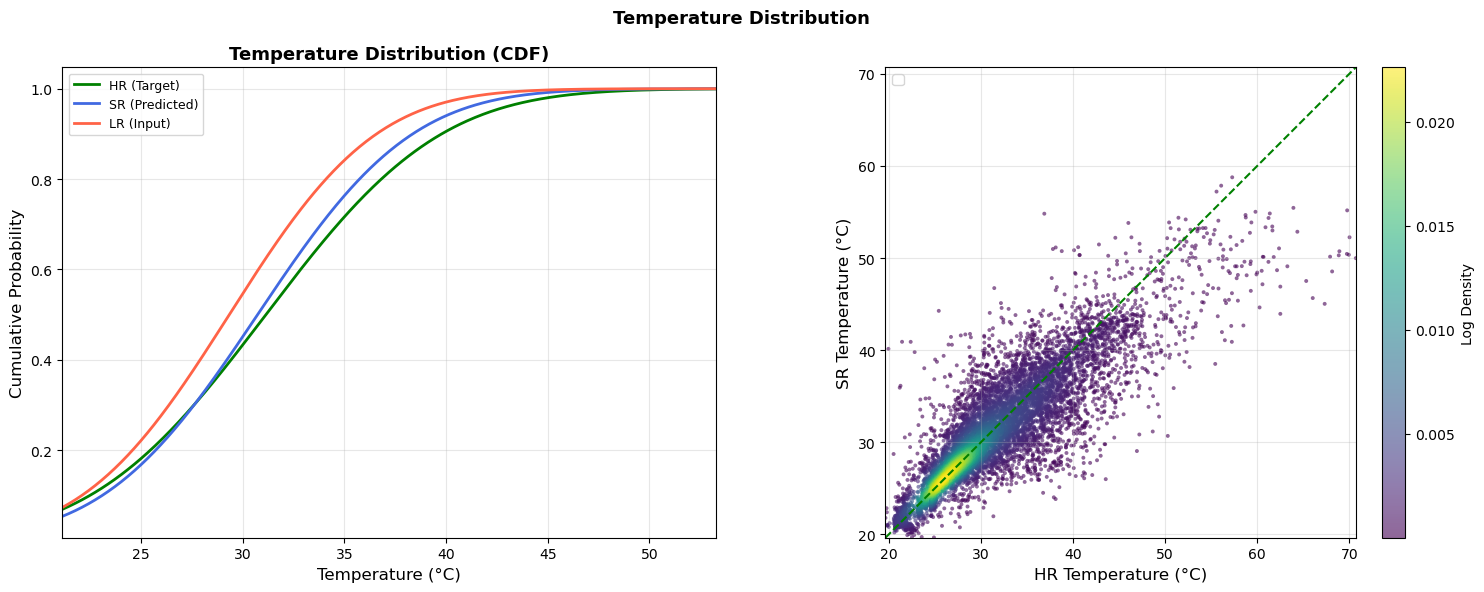

In [8]:
print(f"\nRunning inference on full val set ({len(val_ds)} samples)...")

all_hr, all_sr, all_lr = [], [], []

for i, sample in enumerate(val_ds):
    hr_mask    = sample["hr_mask"].squeeze().numpy()
    valid_mask = hr_mask > 0.5

    if valid_mask.sum() == 0:
        continue

    lr_64  = sample["lr"][0].numpy() * HR_STD + HR_MEAN
    lr_256 = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    hr_np  = sample["hr"][0].numpy() * HR_STD + HR_MEAN

    sr_celsius = run_inference(sample)

    all_hr.append(hr_np[valid_mask])
    all_sr.append(sr_celsius[valid_mask])
    all_lr.append(lr_256[valid_mask])
    # all_lr.append(lr_64)

    if (i + 1) % 50 == 0 or (i + 1) == len(val_ds):
        print(f"  {i + 1}/{len(val_ds)} done")

    torch.cuda.empty_cache()

hr_valid = np.concatenate(all_hr)
sr_valid = np.concatenate(all_sr)
lr_valid = np.concatenate(all_lr)
print(f"Total valid pixels: {len(hr_valid):,}")

vmin = np.percentile(hr_valid, 1)
vmax = np.percentile(hr_valid, 99)

palette = {"HR": "green",  "SR": "royalblue", "LR": "tomato"}
data    = {"HR": hr_valid, "SR": sr_valid,     "LR": lr_valid}
labels  = {"HR": "HR (Target)", "SR": "SR (Predicted)", "LR": "LR (Input)"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Temperature Distribution ",
             fontsize=13, fontweight="bold")

# CDF
ax_cdf = axes[0]
x      = np.linspace(vmin, vmax, 500) 

for key, vals in data.items():
    mu, std = stats.norm.fit(vals)
    ax_cdf.plot(
        x, stats.norm.cdf(x, mu, std),
        color=palette[key], lw=2,
        # label=f"{labels[key]} (μ={mu:.1f}°C, σ={std:.1f}°C)"
        label = f"{labels[key]}"
    )


ax_cdf.set_xlim(vmin, vmax)
ax_cdf.set_xlabel("Temperature (°C)", fontsize=12)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=12)
ax_cdf.set_title("Temperature Distribution (CDF)", fontsize=13, fontweight="bold")
ax_cdf.legend(fontsize=9, loc="upper left")
ax_cdf.grid(True, alpha=0.3)


# Scatter (subsample 10k points for speed)
ax_scat    = axes[1]
n_pts      = min(len(hr_valid), 10_000)
idx_sample = np.random.choice(len(hr_valid), n_pts, replace=False)
hr_s       = hr_valid[idx_sample]
sr_s       = sr_valid[idx_sample]

t_min = min(hr_s.min(), sr_s.min())
t_max = max(hr_s.max(), sr_s.max())

density     = gaussian_kde(np.vstack([hr_s, sr_s]))(np.vstack([hr_s, sr_s]))
log_density = np.log1p(density)
order       = log_density.argsort()

sc = ax_scat.scatter(
    hr_s[order], sr_s[order],
    c=log_density[order], cmap="viridis",
    s=8, alpha=0.6, linewidths=0
)
fig.colorbar(sc, ax=ax_scat, label="Log Density", fraction=0.046, pad=0.04)

ax_scat.plot([t_min, t_max], [t_min, t_max], "g--", lw=1.5)
ax_scat.set_xlim(t_min, t_max)
ax_scat.set_ylim(t_min, t_max)
ax_scat.set_aspect("equal")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=12)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=12)
ax_scat.legend(fontsize=10, loc="upper left")
ax_scat.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()